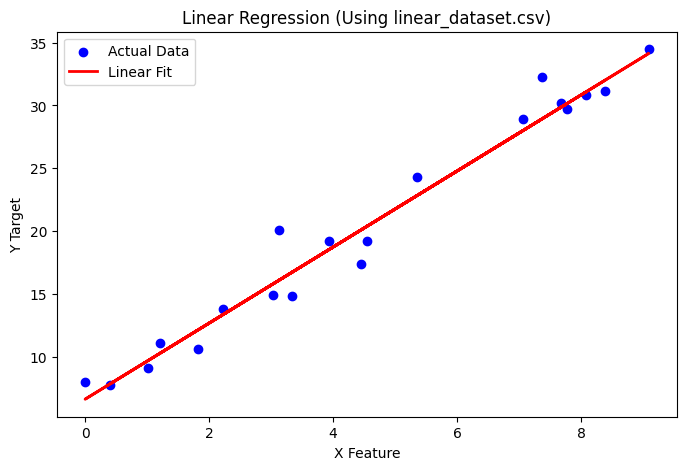

--- Linear Regression Results ---
Mean Squared Error: 2.488168967960058
R^2 Score: 0.9683459445401472


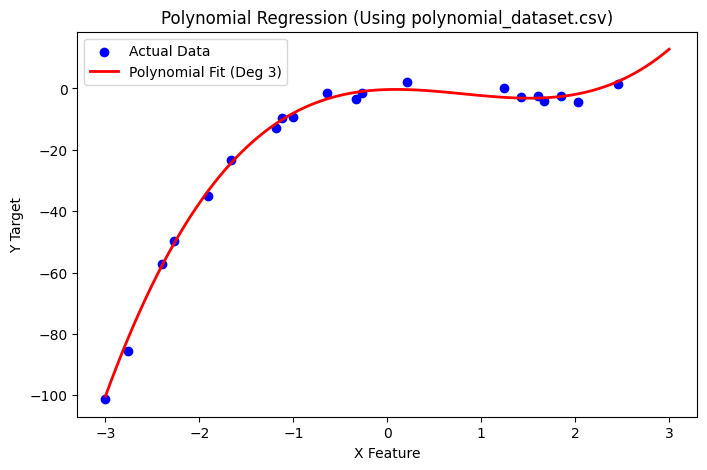


--- Polynomial Regression Results ---
Mean Squared Error: 2.988769545959468
R^2 Score: 0.9965651131267799


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

# --- PART 1: Linear Regression ---
def run_linear_regression():
    # Using the teacher-provided linear_dataset.csv
    data = pd.read_csv("linear_dataset.csv")
    X = data[["X"]].values
    y = data["Y"].values
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    plt.figure(figsize=(8, 5))
    plt.scatter(X_test, y_test, color="blue", label="Actual Data")
    plt.plot(X_test, y_pred, color="red", linewidth=2, label="Linear Fit")
    plt.xlabel("X Feature")
    plt.ylabel("Y Target")
    plt.title("Linear Regression (Using linear_dataset.csv)")
    plt.legend()
    plt.show()
    
    print("--- Linear Regression Results ---")
    print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
    print("R^2 Score:", r2_score(y_test, y_pred))

# --- PART 2: Polynomial Regression ---
def run_polynomial_regression():
    # Using the teacher-provided polynomial_dataset.csv
    data = pd.read_csv("polynomial_dataset.csv")
    X = data[["X"]].values
    y = data["Y"].values
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Create a pipeline: Polynomial Features -> Scaling -> Linear Regression
    # Using degree=2 or 3 to fit the curve
    poly_model = make_pipeline(PolynomialFeatures(degree=3), StandardScaler(), LinearRegression())
    poly_model.fit(X_train, y_train)
    
    # For a smooth curve in the plot, we create a range of values
    X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_range_pred = poly_model.predict(X_range)
    
    plt.figure(figsize=(8, 5))
    plt.scatter(X_test, y_test, color="blue", label="Actual Data")
    plt.plot(X_range, y_range_pred, color="red", linewidth=2, label="Polynomial Fit (Deg 3)")
    plt.xlabel("X Feature")
    plt.ylabel("Y Target")
    plt.title("Polynomial Regression (Using polynomial_dataset.csv)")
    plt.legend()
    plt.show()
    
    y_pred = poly_model.predict(X_test)
    print("\n--- Polynomial Regression Results ---")
    print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
    print("R^2 Score:", r2_score(y_test, y_pred))

if __name__ == "__main__":
    run_linear_regression()
    run_polynomial_regression()